# Predictive Maintenance - Machine Temperature Anomaly Detection

## Objective
Detect abnormal machine behavior using time-series temperature data.

## Step 1
Load dataset and visualize temperature trend.

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

#Load dataset directly from Github
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(url)
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


,timestamp,value
count,22695,22695.000000
mean,2014-01-11 06:16:49.887640576,85.926498
min,2013-12-02 21:15:00,2.084721
25%,2013-12-22 14:02:30,83.080078
50%,2014-01-11 05:50:00,89.408246
75%,2014-01-30 22:37:30,94.016252
max,2014-02-19 15:25:00,108.510543
std,NaN,13.746912


In [4]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
# Checking datatypes after changing the datatype
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


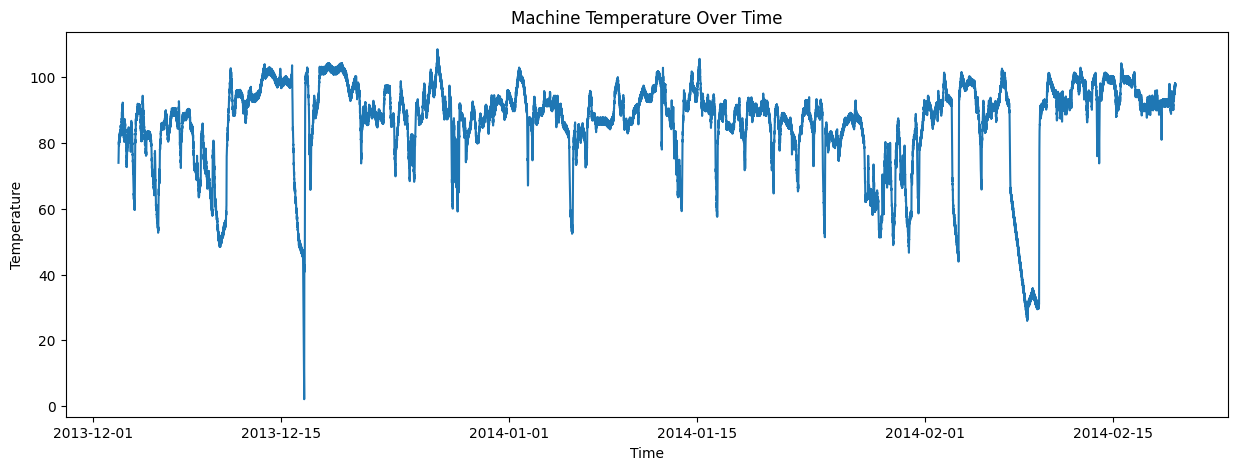

In [ ]:
#Visualizing data
plt.figure(figsize=(15,5))
plt.plot(df['timestamp'],df['value'])
plt.title('Machine Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

In [5]:
# setting timestamp as index
df.set_index('timestamp',inplace=True)
df.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [10]:
# Basic statistics
mean = df['value'].mean()
std = df['value'].std()

print(f"Mean temperature:{mean:.2f}")
print(f"Standard Deviation:{std:.2f}")

<class 'numpy.float64'> <class 'float'>
Mean temperature:85.93
Standard Deviation:13.75


## Adding Rolling mean

After overlaying Rolling mean on the original Temperature. We are seperating two things.
1. Short Time Fluctation(noise): The Original Temperature Line
2. Underlying trend: The rolling mean line

In [13]:
# Adding Rolling mean
df['rolling_mean'] = df['value'].rolling(window=50).mean()

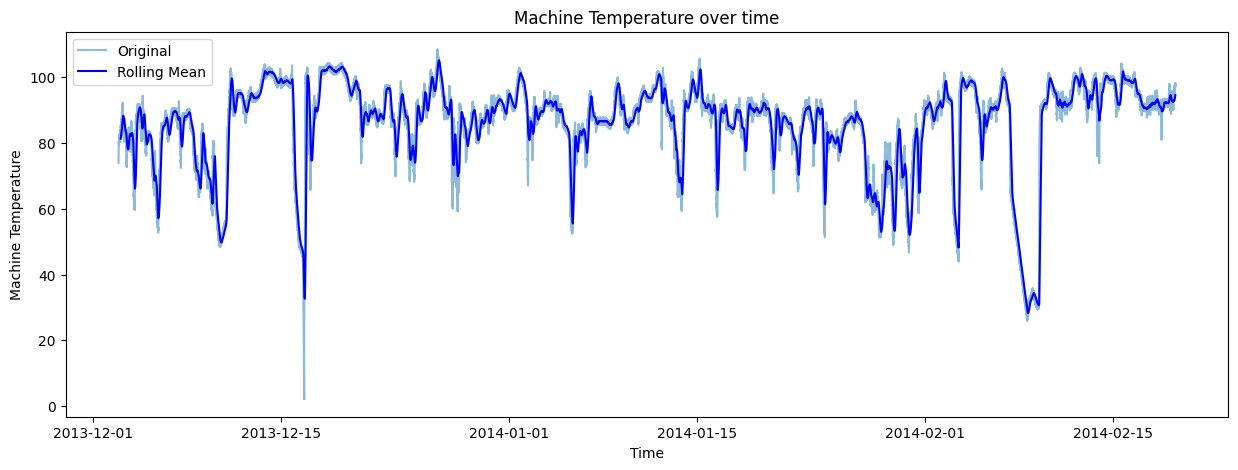

In [17]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.5,label='Original')
plt.plot(df.index,df['rolling_mean'],label='Rolling Mean',color = 'b')
plt.legend()
plt.title('Machine Temperature over time')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

## Observation
During **normal operation** temperature shows random flactuation around a stable baseline.

**Event/Failure behaviour:** The system shows gradual shift in machine temperature , indicating abnormal machine behaviour.